# Imports

In [1]:
import gdown
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import seaborn as sns
import timm
import torch
import torch.nn.functional as F
import cv2

from collections import defaultdict
from PIL import Image, ImageOps
from tqdm import tqdm
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torch.cuda.amp import GradScaler, autocast

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

# Functions

In [2]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [3]:
# Plot random images

def plot_random_images(dataset, gray=False):
    random_idx = np.random.randint(0, len(dataset), 9)

    plt.figure(figsize=(10, 10))
    for i, img_index in enumerate(random_idx):
        plt.subplot(3,3,i+1)
        plt.grid(False)
        image, label = dataset[img_index]
        plt.title(label)
        if gray:
          plt.imshow(image.permute(1,2,0), cmap='gray')
        else:
          plt.imshow(image.permute(1,2,0))
    
    plt.show()

In [4]:
def plot_original_vs_augmented(dataset, num_images=5):
    
    random_idx = np.random.randint(0, len(dataset), num_images)
    
    plt.figure(figsize=(3 * num_images, 6))
    
    for i, idx in enumerate(random_idx):
        img_path, label_idx = dataset.samples[idx]
        
        label_name = dataset.classes[label_idx] 
        
        img_original = Image.open(img_path).convert('RGB')
        
        img_augmented, _ = dataset[idx] 
        
        plt.subplot(2, num_images, i + 1)
        plt.imshow(img_original)
        plt.title(f"{label_name}\n(Original)", fontsize=10)
        plt.axis('off')
        
        plt.subplot(2, num_images, i + 1 + num_images)
        
        img_aug_np = img_augmented.permute(1, 2, 0).numpy()
        
        img_aug_np = np.clip(img_aug_np, 0, 1)
        
        plt.imshow(img_aug_np)
        plt.title(f"{label_name}\n(Augmented)", fontsize=10)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

In [5]:
# Plot confusion matrix

def plot_confusion_matrix_with_diagonal(
    cm,
    labels,
    title_matrix='Normalized Confusion Matrix',
    title_diagonal='Class Accuracies',
    extra_diagonals=None,
    extra_names=None
):

    row_sums = cm.sum(axis=1)

    sorted_indices = np.argsort(row_sums)[::-1]

    cm_sorted = cm[sorted_indices][:, sorted_indices]
    labels_sorted = [labels[i] for i in sorted_indices]

    cm_normalized = cm_sorted.astype('float') / cm_sorted.sum(axis=1)[:, np.newaxis]
    diagonal = np.diag(cm_normalized)

    accuracy_rows = [diagonal]
    accuracy_labels = [title_diagonal]

    if extra_diagonals is not None:
        accuracy_rows += extra_diagonals
    if extra_names is not None:
        accuracy_labels += extra_names
    elif extra_diagonals:
        accuracy_labels += [f'Modelo {i+1}' for i in range(len(extra_diagonals))]

    sns.set(font_scale=1.0)

    fig = plt.figure(figsize=(14, 16))

    ax1 = plt.subplot2grid((6, 1), (0, 0), rowspan=4)
    sns.heatmap(cm_normalized, annot=np.round(cm_normalized, 2), fmt=".2f", cmap='flare',
                xticklabels=labels_sorted, yticklabels=labels_sorted, linewidths=0.5,
                cbar=True, annot_kws={"size": 8}, ax=ax1)
    ax1.set_title(title_matrix)
    ax1.set_xlabel('Prediction')
    ax1.set_ylabel('Real')
    ax1.tick_params(axis='x', rotation=90)
    ax1.tick_params(axis='y', rotation=0)

    ax2 = plt.subplot2grid((6, 1), (4, 0), rowspan=2)
    sns.heatmap(accuracy_rows, annot=np.round(accuracy_rows, 2), fmt=".2f", cmap='flare',
                xticklabels=labels_sorted, yticklabels=accuracy_labels, cbar=True,
                linewidths=0.5, ax=ax2)
    ax2.tick_params(axis='x', rotation=90)
    ax2.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()


In [7]:
# Auxiliar function for train_classification()

def _train_step_classification(classifier_model, dataloader, criterion, optimizer, scheduler, device, scaler):
    classifier_model.train()

    total_loss = 0
    all_preds = []
    all_targets = []

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        with autocast():
            y_pred = classifier_model(X)
            loss = criterion(y_pred, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * X.size(0)

        y_pred_labels = torch.argmax(y_pred, axis=1)
        all_preds.extend(y_pred_labels.detach().cpu().numpy())
        all_targets.extend(y.detach().cpu().numpy())

    if scheduler:
        if not isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step()

    mean_loss = total_loss / len(dataloader.dataset)
    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)

    return mean_loss, accuracy, precision, recall, f1

In [8]:
# Auxiliar function for train_classification()

def _test_step_classification(classifier_model, dataloader, criterion, device):
    classifier_model.eval()

    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y_pred = classifier_model(X)
            loss = criterion(y_pred, y)

            total_loss += loss.item() * X.size(0)

            y_pred_labels = torch.argmax(y_pred, axis=1)
            all_preds.extend(y_pred_labels.detach().cpu().numpy())
            all_targets.extend(y.detach().cpu().numpy())

    mean_loss = total_loss / len(dataloader.dataset)
    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)

    return mean_loss, accuracy, precision, recall, f1

In [10]:
# Treina rede de classificação

def train_classification(classifier_model, train_dataloader, test_dataloader, criterion, epochs, optimizers, schedulers, device='cpu', verbose=True):
    metrics = {'Train loss': [], 'Train accuracy': [], 'Train precision': [], 'Train recall': [], 'Train F1': [],
               'Test loss': [], 'Test accuracy': [], 'Test precision': [], 'Test recall': [], 'Test F1': []}

    scaler = GradScaler()

    
    current_optimizer_number = 0
    for optimizer, scheduler, num_epochs in zip(optimizers, schedulers, epochs):
        current_optimizer_number += 1
        for epoch in tqdm(range(1, num_epochs+1), desc=f'Training with optimizer {current_optimizer_number}'):
            current_lr = optimizer.param_groups[0]["lr"]
            train_loss, train_accuracy, train_precision, train_recall, train_f1= _train_step_classification(classifier_model, train_dataloader, criterion, optimizer, scheduler, device, scaler=scaler)
            test_loss, test_accuracy, test_precision, test_recall, test_f1 = _test_step_classification(classifier_model, test_dataloader, criterion, device)

            metrics['Train loss'].append(train_loss)
            metrics['Train accuracy'].append(train_accuracy)
            metrics['Train precision'].append(train_precision)
            metrics['Train recall'].append(train_recall)
            metrics['Train F1'].append(train_f1)
            metrics['Test loss'].append(test_loss)
            metrics['Test accuracy'].append(test_accuracy)
            metrics['Test precision'].append(test_precision)
            metrics['Test recall'].append(test_recall)
            metrics['Test F1'].append(test_f1)

            if verbose:
                print(f'\nEPOCH {epoch} | Current learning rate: {current_lr:.8f}\n'
                      f'Train loss: {train_loss:.4f} | Train accuracy: {train_accuracy:.4f} | Train precision: {train_precision:.4f} | Train recall: {train_recall:.4f} | Train F1: {train_f1:.4f}\n'
                      f'Test loss: {test_loss:.4f} | Test accuracy: {test_accuracy:.4f} | Test precision: {test_precision:.4f} | Test recall: {test_recall:.4f} | Test F1: {test_f1:.4f}\n')

    return metrics

In [11]:
# Returns confusion matrix

def get_conf_matrix(classifier_model, dataloader, device):
    classifier_model.eval()

    all_preds = []
    all_targets = []

    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y_pred = classifier_model(X).argmax(dim=1).cpu()

            all_preds.extend(y_pred.cpu())
            all_targets.extend(y.cpu())

    conf_matrix = confusion_matrix(all_targets, all_preds)

    return conf_matrix

In [12]:
# Improves augmentation through color stain

def random_stain_augmentation(pil_img, alpha_std=0.05, beta_std=0.02):
    img = np.array(pil_img)

    if img.shape[2] != 3:
        raise ValueError("The image needs 3 RBG channels")

    he_matrix = np.array([
        [0.644211, 0.716556, 0.266844],
        [0.092789, 0.954111, 0.283111]
    ])

    img = img.astype(np.float32) + 1 
    od = -np.log(img / 255)

    h, w, c = od.shape
    od_flat = od.reshape(-1, 3) 

    stain_concentrations = np.dot(od_flat, np.linalg.pinv(he_matrix))  # [h*w, 2]

    
    alpha = np.random.normal(1.0, alpha_std, size=(2,))
    beta = np.random.normal(0.0, beta_std, size=(2,))
    stain_concentrations *= alpha
    stain_concentrations += beta

   
    recon_od = np.dot(stain_concentrations, he_matrix)  # [h*w, 3]
    recon_od = recon_od.reshape(h, w, 3)

    recon_img = np.exp(-recon_od) * 255
    recon_img = np.clip(recon_img, 0, 255).astype(np.uint8)

    return Image.fromarray(recon_img)

In [13]:
class StainAugmentationWrapper:
    def __init__(self, base_transform, p=0.5):
        self.base_transform = base_transform
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:  
            img = random_stain_augmentation(img)
        return self.base_transform(img)

In [14]:
"""def remove_attention(model):

    for name, module in model.named_children():

        # If the module is an attention layer
        if "attn" in name.lower():
            setattr(model, name, nn.Identity())
        
        # If its a SwinTransformerBlock (with function _attn)
        elif hasattr(module, "_attn"):
            def no_attn(x, mask=None):
                return x
            module._attn = no_attn

        # Recursively replaces inside the submodules
        else:
            remove_attention(module)"""

# Dataset

In [15]:
print(os.listdir("/kaggle/input/BM_cytomorphology_train_test/BM_cytomorphology_data"))
folder_path = '/kaggle/input/BM_cytomorphology_train_test/BM_cytomorphology_data'

['Test', 'Train']


In [16]:
total_train_samples = 0
print('TRAIN SAMPLES')
for dir in sorted(os.listdir(f'{folder_path}/Train')):
  n_samples = len(os.listdir(f'{folder_path }/Train/{dir}'))
  total_train_samples += n_samples
  print(f'{dir}: {n_samples} Samples')

print('-'*20)
print(f'Total (Train): {total_train_samples}\n')

total_test_samples = 0
print('TEST SAMPLES')
for dir in sorted(os.listdir(f'{folder_path}/Test')):
  n_samples = len(os.listdir(f'{folder_path}/Test/{dir}'))
  total_test_samples += n_samples
  print(f'{dir}: {n_samples} Samples')

print('-'*20)
print(f'Total (Test): {total_test_samples}\n')
print('-'*20)
print(f'Total samples: {total_train_samples + total_test_samples}')

AMOSTRAS DE TREINO
ABE: 6 Amostras
ART: 15704 Amostras
BAS: 352 Amostras
BLA: 9578 Amostras
EBO: 21916 Amostras
EOS: 4706 Amostras
FGC: 37 Amostras
HAC: 327 Amostras
KSC: 33 Amostras
LYI: 52 Amostras
LYT: 20993 Amostras
MMZ: 2444 Amostras
MON: 3232 Amostras
MYB: 5244 Amostras
NGB: 7974 Amostras
NGS: 23539 Amostras
NIF: 2830 Amostras
OTH: 235 Amostras
PEB: 2192 Amostras
PLM: 6103 Amostras
PMO: 9594 Amostras
--------------------
Total (Treino): 137091

AMOSTRAS DE TESTE
ABE: 2 Amostras
ART: 3926 Amostras
BAS: 89 Amostras
BLA: 2395 Amostras
EBO: 5479 Amostras
EOS: 1177 Amostras
FGC: 10 Amostras
HAC: 82 Amostras
KSC: 9 Amostras
LYI: 13 Amostras
LYT: 5249 Amostras
MMZ: 611 Amostras
MON: 808 Amostras
MYB: 1312 Amostras
NGB: 1994 Amostras
NGS: 5885 Amostras
NIF: 708 Amostras
OTH: 59 Amostras
PEB: 548 Amostras
PLM: 1526 Amostras
PMO: 2399 Amostras
--------------------
Total (Teste): 34281

--------------------
Amostras totais: 171372


In [17]:
transform = StainAugmentationWrapper(transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(degrees=30, translate=(0.00, 0.00), scale=(1.00, 1.00), shear=5),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
]), p=0.5)

test_transform = transforms.Compose([
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

In [18]:
train_dataset = ImageFolder(root=f'{folder_path}/Train', transform=transform)
test_dataset = ImageFolder(root=f'{folder_path}/Test', transform=test_transform)

In [19]:
targets = [sample[1] for sample in train_dataset.samples]

class_count = np.bincount(targets)

# Defines the minimum target amount
MIN_SAMPLES = 100 

target_counts = [max(MIN_SAMPLES, count) for count in class_count]

# Weight = Target / Real
class_weights = [target / real for target, real in zip(target_counts, class_count)]

sample_weights = [class_weights[t] for t in targets]

total_target_samples = int(sum(target_counts))

train_sampler = WeightedRandomSampler(weights=sample_weights,
                                num_samples=total_target_samples,
                                replacement=True)

print(f"Original classes: {class_count}")
print(f"Train targets: {target_counts}")

Classes originais: [    6 15704   352  9578 21916  4706    37   327    33    52 20993  2444
  3232  5244  7974 23539  2830   235  2192  6103  9594]
Metas de treino: [100, np.int64(15704), np.int64(352), np.int64(9578), np.int64(21916), np.int64(4706), 100, np.int64(327), 100, 100, np.int64(20993), np.int64(2444), np.int64(3232), np.int64(5244), np.int64(7974), np.int64(23539), np.int64(2830), np.int64(235), np.int64(2192), np.int64(6103), np.int64(9594)]


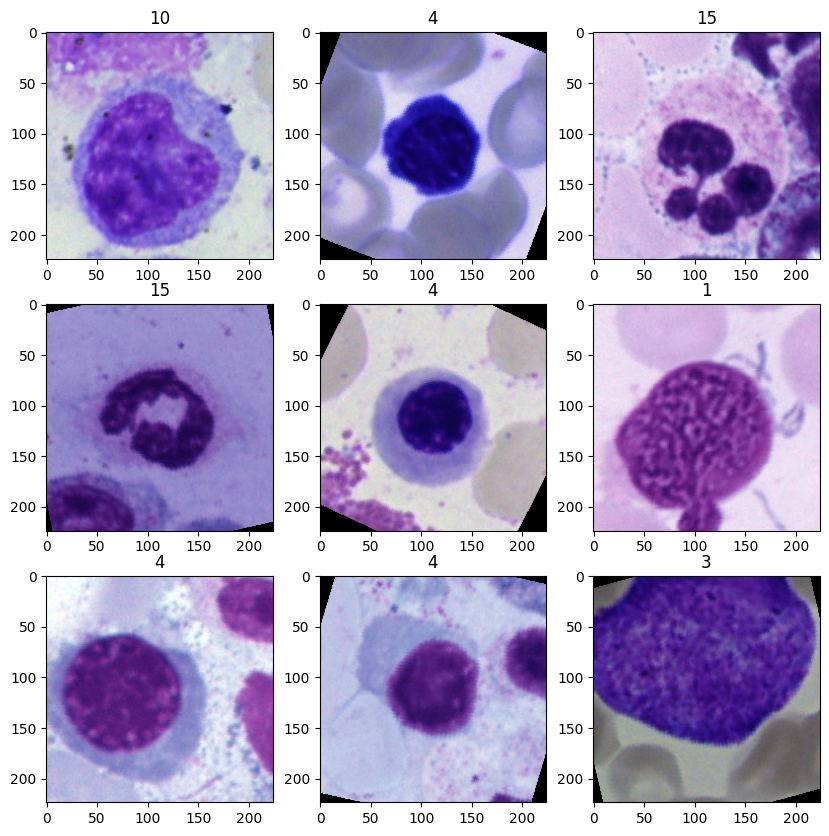

In [20]:
plot_random_images(train_dataset)

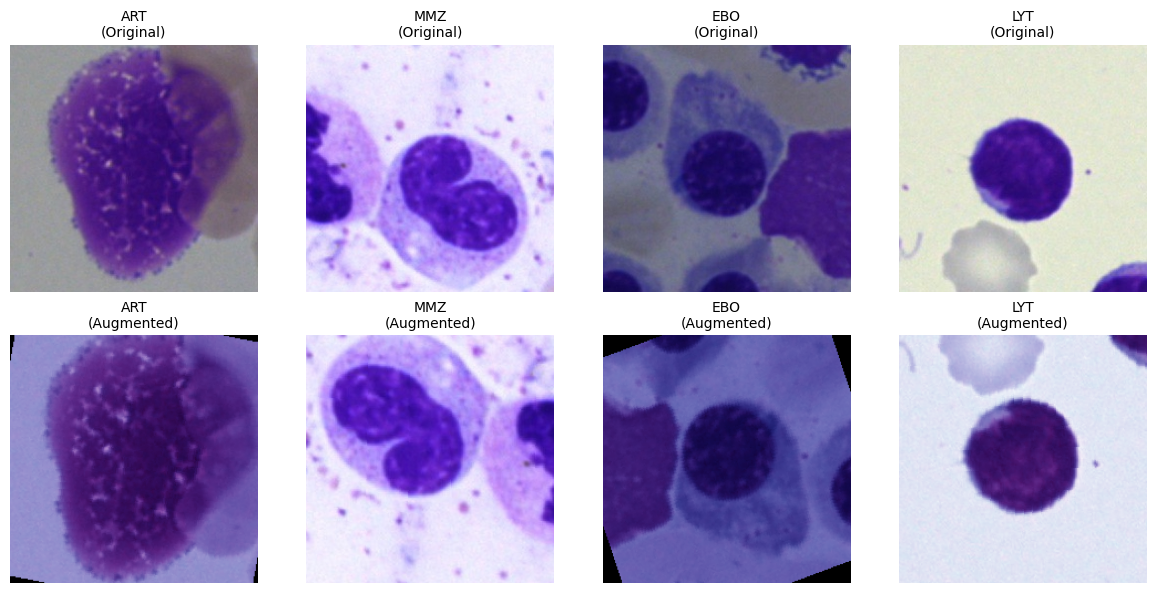

In [21]:
plot_original_vs_augmented(train_dataset, num_images=4)

# Model

# Training

In [22]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [23]:
train_dataloader = DataLoader(train_dataset, batch_size=48, shuffle=False, sampler=train_sampler, num_workers=4, prefetch_factor=4, pin_memory=True, persistent_workers=True)
test_dataloader = DataLoader(test_dataset, batch_size=48, shuffle=False, num_workers=4, prefetch_factor=4, pin_memory=True, persistent_workers=True)

## Classification

In [24]:

class SwinTransformerTiny(nn.Module):
    def __init__(self, drop_path_rate=0, drop_rate=0, attn_drop_rate=0):
        super().__init__()
        self.model = timm.create_model(
            'swin_tiny_patch4_window7_224', 
            pretrained=True,
            num_classes=21,                 
            drop_path_rate=drop_path_rate, 
            drop_rate=drop_rate,            
            attn_drop_rate=attn_drop_rate
        )

    def forward(self, x):
        return self.model(x)
        

In [25]:
classifier_model = SwinTransformerTiny(drop_path_rate=0.3, drop_rate=0.2, attn_drop_rate=0.0).to(device)
criterion = FocalLoss(gamma=2.0, alpha=1.0).to(device)
optimizer = optim.AdamW(classifier_model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, 1, 0.8)
optimizers = [optimizer]
schedulers = [scheduler]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

In [26]:
# Download parameters from Google Drive, if necessary
#gdown.download('https://drive.google.com/file/d/1qODrihNee0YU_ChD_WWNA45MQMLUCxef/view?usp=sharing', 'parameters.pth', fuzzy=True, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1qODrihNee0YU_ChD_WWNA45MQMLUCxef
From (redirected): https://drive.google.com/uc?id=1qODrihNee0YU_ChD_WWNA45MQMLUCxef&confirm=t&uuid=a10609ce-920e-406b-bf14-5b1f8b8f7c47
To: /kaggle/working/parameters.pth
100%|██████████| 261M/261M [00:11<00:00, 22.9MB/s] 


'parameters.pth'

In [ ]:
# If you are STARTING TRAINING, use this block of code
epochs = [10]
metrics = train_classification(classifier_model, train_dataloader, test_dataloader, criterion, epochs, optimizers, schedulers, device)

In [ ]:
"""
# If you are RESUMING TRAINING, use this block of code

classifier_model = SwinTransformerTiny(drop_path_rate=0.3, drop_rate=0.2, attn_drop_rate=0.0).to(device)
#remove_attention(classifier_model)
optimizer = optim.AdamW(classifier_model.parameters(), lr=1e-4, weight_decay=1e-5) 
# Nota: The LR in the constructor will be overwritten by the load_state_dict
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.8)
criterion = FocalLoss(gamma=2.0, alpha=1.0).to(device)
checkpoint = torch.load('/kaggle/working/parameters.pth', weights_only=False)

classifier_model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

metrics_anteriores = checkpoint['metrics']
start_epoch = checkpoint['epoch']

print(f"Resuming training from epoch {start_epoch + 1}...")

new_epochs = [10] 
new_metrics = train_classification(
    classifier_model, 
    train_dataloader, 
    test_dataloader, 
    criterion, 
    new_epochs, 
    [optimizer], 
    [scheduler], 
    device
)
"""

In [ ]:
checkpoint = {
    'epoch': 15,
    'model_state_dict': classifier_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'metrics': new_metrics
    #'metrics': metrics
}
torch.save(checkpoint, 'swintiny_checkpoint_epoch.pth')
print("Checkpoint saved successfully")

# Metrics

In [24]:
# Class names

labels = sorted(os.listdir(f'{folder_path}/Train'))
labels[0] = 'Abnormal eosinophil'
labels[1] = 'Artefact'
labels[2] = 'Basophil'
labels[3] = 'Blast'
labels[4] = 'Erythroblast'
labels[5] = 'Eosinophil'
labels[6] = 'Faggott cell'
labels[7] = 'Hairy cell'
labels[8] = 'Smudge cell'
labels[9] = 'Immature lymphocyte'
labels[10] = 'Lymphocyte'
labels[11] = 'Metamyelocyte'
labels[12] = 'Monocyte'
labels[13] = 'Myelocyte'
labels[14] = 'Band neutrophil'
labels[15] = 'Segmented neutrophil'
labels[16] = 'Not identifiable'
labels[17] = 'Other cell'
labels[18] = 'Proerythroblast'
labels[19] = 'Plasma cell'
labels[20] = 'Promyelocyte'

In [25]:
# Metrics from other authors

matek_accuracies = [0.71, 0.82, 0.70, 0.74, 0.72, 0.65, 0.65, 0.84, 0.59, 0.91, 0.70, 0.63, 0.64, 0.63, 0.64, 0.80, 0.84, 0.53, 0.63, 0.90, 0.20]
nielsen_accuracies = [0.73, 0.79, 0.69, 0.71, 0.69, 0.64, 0.65, 0.81, 0.58, 0.90, 0.63, 0.63, 0.47, 0.82, 0.64, 0.84, 0.80, 0.83, 0.45, 0.95, 0.97]
ananthakrishnan_accuracies = [0.97, 0.82, 0.62, 0.92, 0.93, 0.89, 0.85, 0.93, 0.89, 0.93, 0.49, 0.82, 0.81, 0.84, 0.35, 0.77, 0.21, 0.91, 0.53, 1.00, 1.00]

In [ ]:
conf_matrix = get_conf_matrix(classifier_model, test_dataloader, device)

In [ ]:
# Confusion matrix
plot_confusion_matrix_with_diagonal(conf_matrix, labels, title_diagonal='Swin Tiny', extra_diagonals=[matek_accuracies, nielsen_accuracies, ananthakrishnan_accuracies], extra_names=['Matek et al.', 'Nielsen et al.', 'Ananthakrishnan et al.'])